In [22]:
import os
import glob
import re
import h5py
import numpy as np
import pandas as pd
from typing import Tuple, Literal, Optional, List
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from scipy.signal import decimate
import matplotlib.pyplot as plt
import itertools
# For CNN/RNN
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, InputLayer
)
from tensorflow.keras.optimizers import Adam




In [23]:

_CHUNK_RE = re.compile(r'_(\d+)\.h5$')          # capture the trailing “…_<chunk>.h5”

def _get_dataset_name(path: str) -> str:
    """Return the internal dataset name inside the HDF5 file."""
    return "_".join(os.path.basename(path).split('_')[:-1])
#C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Intra\train
def load_participant_arrays(participant_id: int, base_dir: str = "\train"):
    """
    Concatenate all chunks for every task of one participant and return
    four NumPy arrays in the order:
        rest, task_motor, task_story_math, task_working_memory

    Each array has shape (n_nodes, total_timepoints) or is None.
    """
    # buckets: task → list[(chunk_number, matrix)]
    buckets = {
        "rest":               [],
        "task_motor":         [],
        "task_story_math":    [],
        "task_working_memory": []
    }

    # find all relevant files, e.g. rest_105923_1.h5
    pattern = os.path.join(base_dir, f"*_{participant_id}_*.h5")
    for path in glob.glob(pattern):
        ds_name = _get_dataset_name(path)

        # identify task & chunk number
        task = next((t for t in buckets if ds_name.startswith(t)), None)
        if task is None:
            continue  # skip unrecognised file

        chunk_match = _CHUNK_RE.search(path)
        chunk_num = int(chunk_match.group(1)) if chunk_match else 0

        # load matrix
        with h5py.File(path, "r") as f:
            matrix = f[ds_name][()]        # (nodes, timepoints)

        buckets[task].append((chunk_num, matrix))

    # concatenate chunks for each task
    out = []
    for task, lst in buckets.items():
        if not lst:
            out.append(None)
            continue

        # sort by chunk number to keep temporal order
        lst.sort(key=lambda item: item[0])
        matrices = [m for _, m in lst]

        # sanity‑check dimensionality: all chunks must share the node axis size
        first_rows = matrices[0].shape[0]
        if not all(mat.shape[0] == first_rows for mat in matrices):
            raise ValueError(f"Inconsistent node counts in {task} chunks for participant {participant_id}")

        # concat along time axis (axis=1)
        out.append(np.concatenate(matrices, axis=1))

    return tuple(out)  # (rest, motor, story_math, working_memory)


# Training

## Intra Files

In [24]:
## TRAINING DATA ##

# intra 1
participant_id_intra = 105923
rest_intra, motor_intra, story_math_intra, wm_intra = load_participant_arrays(participant_id_intra, base_dir=r"D:\DL project 2\Final Project data\Final Project data\Intra\train")


print("Rest:", None if rest_intra is None else rest_intra.shape)
print("Motor:", None if motor_intra is None else motor_intra.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra.shape)
print("Working Memory:", None if wm_intra is None else wm_intra.shape)


Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


## Contra Files

In [25]:
## TRAINING DATA ##

# contra 1
participant_id_c1 = 113922

#contra 2
participant_id_c2 = 164636


rest_c1, motor_c1, story_math_c1, wm_c1 = load_participant_arrays(participant_id_c1, base_dir=r"D:\DL project 2\Final Project data\Final Project data\Cross\train")
rest_c2, motor_c2, story_math_c2, wm_c2 = load_participant_arrays(participant_id_c2, base_dir=r"D:\DL project 2\Final Project data\Final Project data\Cross\train")


print("Rest:", None if rest_c2 is None else rest_c2.shape)
print("Motor:", None if motor_c2 is None else motor_c2.shape)
print("Story/Math:", None if story_math_c2 is None else story_math_c2.shape)
print("Working Memory:", None if wm_c2 is None else wm_c2.shape)

Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


In [26]:
# Suppose `rest_arr` has shape (248, 35624)
'''
rest_scaled  = minmax_scale(rest_intra)          # values in [0, 1]
rest_standardised = zscore(rest_intra)           # mean 0 / std 1
rest_down128 = downsample(rest_intra, target_rate=128)   # ≈128 Hz via slicing'''


'\nrest_scaled  = minmax_scale(rest_intra)          # values in [0,\u202f1]\nrest_standardised = zscore(rest_intra)           # mean 0 / std 1\nrest_down128 = downsample(rest_intra, target_rate=128)   # ≈128\u202fHz via slicing'

In [27]:
#print(rest_scaled.mean())

## Training Intra

In [28]:
def preprocess_meg_data(
    arr: np.ndarray,
    *, #specify by keyword
    scaling: Literal["zscore", "minmax"] = "zscore",
    axis: int = 1,  # time axis
    downsample_method: Literal["slice", "decimate"] = "decimate",
    downsample_factor: Optional[int] = None,
    target_rate: Optional[int] = None,
    orig_rate: int = 2034,
    eps: float = 1e-12
) -> np.ndarray:
    """
    Scale and downsample MEG data.

    Parameters:
        arr: 2D MEG array [sensors x time]
        scaling: "zscore" or "minmax"
        axis: Axis along which to scale and downsample (default: time)
        downsample_method: "slice" or "decimate"
        downsample_factor: Optional integer downsampling factor
        target_rate: Optional new sample rate (alternative to factor)
        orig_rate: Original sample rate (used with target_rate)
        eps: Stability term

    Returns:
        Preprocessed MEG array [sensors x reduced_time]
    """
    # Scaling/Normalization
    if scaling == "zscore":
        means = arr.mean(axis=axis, keepdims=True)
        stds = arr.std(axis=axis, keepdims=True)
        arr = (arr - means) / (stds + eps)
    elif scaling == "minmax":
        mins = arr.min(axis=axis, keepdims=True)
        maxs = arr.max(axis=axis, keepdims=True)
        arr = (arr - mins) / (maxs - mins + eps)
    else:
        raise ValueError("scaling must be 'zscore' or 'minmax'")

    # Downsampling
    if downsample_factor is None:
        if target_rate is None:
            raise ValueError("Specify either downsample_factor or target_rate")
        downsample_factor = int(round(orig_rate / target_rate))

    if downsample_factor > 1:
        if downsample_method == "slice":
            slicer = [slice(None)] * arr.ndim
            slicer[axis] = slice(None, None, downsample_factor)
            arr = arr[tuple(slicer)]
        elif downsample_method == "decimate":
            arr = decimate(arr, downsample_factor, axis=axis, zero_phase=True)
        else:
            raise ValueError("downsample_method must be 'slice' or 'decimate'")

    return arr


In [29]:
def cossim_cluster_multi_task(task_list, n_clusters=5):
    """
    output:
        sorted_indices: Indices that reorder sensors by cluster.
        labels: Cluster labels for each sensor.
        avg_sim_matrix: Averaged cosine similarity matrix.
    """

    # cosine similarity matrix for each task
    sim_matrices = []
    for task in task_list:
        sim = cosine_similarity(task)
        sim_matrices.append(sim)

    # avg similarity matrices
    avg_sim_matrix = np.mean(sim_matrices, axis=0)
    avg_dist_matrix = 1 - avg_sim_matrix

    # clustering
    clustering = AgglomerativeClustering(
        metric='precomputed',
        linkage='average',
        n_clusters=n_clusters
    )
    labels = clustering.fit_predict(avg_dist_matrix)

    # reorder indices
    sorted_indices = np.argsort(labels)

    return sorted_indices, labels, avg_sim_matrix


In [30]:
datasets = [rest_intra, motor_intra, story_math_intra, wm_intra]
task_names = ["rest", "motor", "story_math", "wm"]

# preprocessing all datasets
preprocessed_datasets = [
    preprocess_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=128,
        orig_rate=2034
    )
    for data in datasets
]

# clustering using averaged cosine similarity
sensor_order, cluster_labels, avg_sim_matrix = cossim_cluster_multi_task(
    preprocessed_datasets,
    n_clusters=5
)

# reorder and store data per task
reordered_data_dict = {}
sensor_order_dict = {}
cluster_labels_dict = {}

for preproc_data, name in zip(preprocessed_datasets, task_names):
    reordered_data = preproc_data[sensor_order, :]
    reordered_data_dict[f"reordered_data_{name}"] = reordered_data
    sensor_order_dict[f"sensor_order_{name}"] = sensor_order
    cluster_labels_dict[f"cluster_labels_{name}"] = cluster_labels




In [31]:
# maybe not the most efficient way oops
rest_data = reordered_data_dict["reordered_data_rest"]
rest_sensor_order = sensor_order_dict["sensor_order_rest"]
rest_clusters = cluster_labels_dict["cluster_labels_rest"]

motor_data = reordered_data_dict["reordered_data_motor"]
motor_sensor_order = sensor_order_dict["sensor_order_motor"]
motor_clusters = cluster_labels_dict["cluster_labels_motor"]

story_math_data = reordered_data_dict["reordered_data_story_math"]
story_math_sensor_order = sensor_order_dict["sensor_order_story_math"]
story_math_clusters = cluster_labels_dict["cluster_labels_story_math"]

wm_data = reordered_data_dict["reordered_data_wm"]
wm_sensor_order = sensor_order_dict["sensor_order_wm"]
wm_clusters = cluster_labels_dict["cluster_labels_wm"]


In [32]:
print(motor_data.shape)

(248, 17812)


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Optional, List

def plot_avg_sensor_similarity(
    sim_matrix: np.ndarray,
    sensor_order: Optional[np.ndarray] = None,
    cluster_labels: Optional[np.ndarray] = None,
    figsize: tuple = (10, 8),
    title: str = "Average Sensor Similarity Across Tasks",
    cmap: str = "viridis"
):
    """
        sim_matrix: 2D numpy array [sensors x sensors], average cosine similarity matrix.
        sensor_order: array of reordered sensor indices.
        cluster_labels: array of cluster labels (used to mark cluster boundaries).

    """
    # Apply sensor reordering if provided
    if sensor_order is not None:
        sim_matrix = sim_matrix[np.ix_(sensor_order, sensor_order)]
        if cluster_labels is not None:
            cluster_labels = np.array(cluster_labels)[sensor_order]

    plt.figure(figsize=figsize)
    sns.heatmap(sim_matrix, cmap=cmap, square=True, cbar=True)
    plt.title(title)
    plt.xlabel("Sensors")
    plt.ylabel("Sensors")

    # Optional: draw lines between clusters
    if cluster_labels is not None:
        boundaries = []
        last_label = cluster_labels[0]
        for i, lbl in enumerate(cluster_labels):
            if lbl != last_label:
                boundaries.append(i)
                last_label = lbl
        for b in boundaries:
            plt.axhline(b, color='white', lw=1)
            plt.axvline(b, color='white', lw=1)

    plt.tight_layout()
    plt.show()


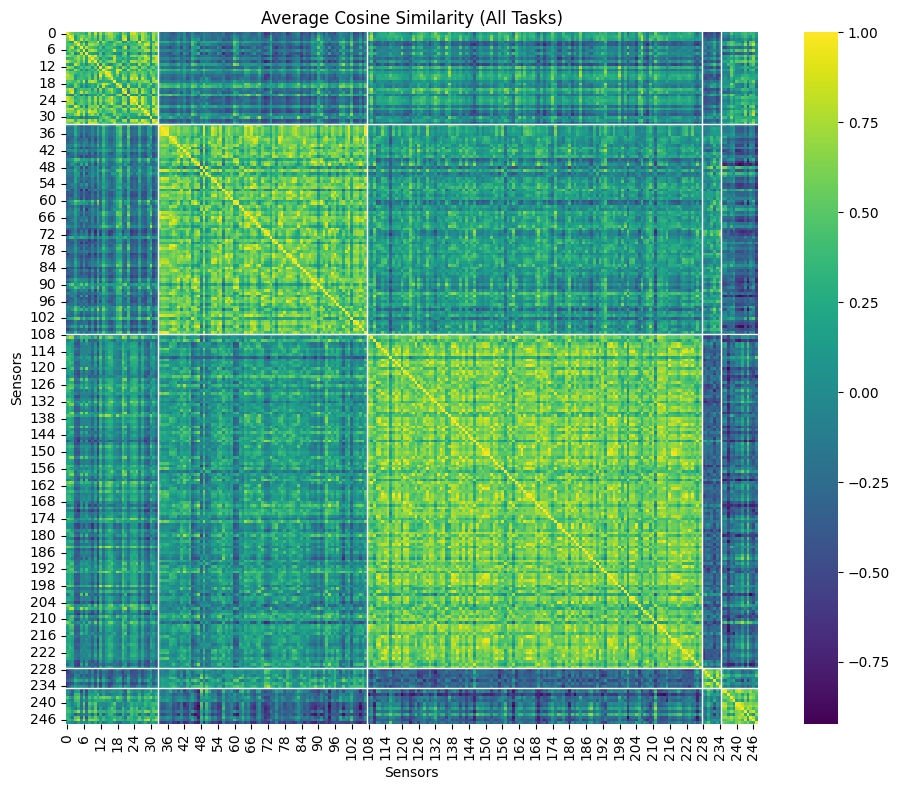

In [34]:
plot_avg_sensor_similarity(
    sim_matrix=avg_sim_matrix,
    sensor_order=sensor_order,
    cluster_labels=cluster_labels,
    title="Average Cosine Similarity (All Tasks)"
)


## Create training/validation sets for models

In [35]:
def make_sequences(data, time_per_snapshot=128, sequence_length=10):
    """
    non-overlapping windows. I'm not really use if this is how we should make teh sequences and create training/val instance
    """
    sensors, total_time = data.shape
    snapshot_stride = time_per_snapshot * sequence_length
    num_sequences = total_time // snapshot_stride

    X = np.zeros((num_sequences, sequence_length, sensors, time_per_snapshot))

    for i in range(num_sequences):
        for j in range(sequence_length):
            start = (i * snapshot_stride) + (j * time_per_snapshot)
            end = start + time_per_snapshot
            X[i, j] = data[:, start:end]

    return X


In [36]:
time_per_snapshot = 128       # 1s per snapshot isince it's sampled at 128 Hz
sequence_length = 10          # 10 snapshots per sequence (10s)
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

# create input sequences
X_rest = make_sequences(rest_data, time_per_snapshot, sequence_length)
X_motor = make_sequences(motor_data, time_per_snapshot, sequence_length)
X_story = make_sequences(story_math_data, time_per_snapshot, sequence_length)
X_wm = make_sequences(wm_data, time_per_snapshot, sequence_length)

# output labels
y_rest = np.full((X_rest.shape[0],), label_map["rest"])
y_motor = np.full((X_motor.shape[0],), label_map["motor"])
y_story = np.full((X_story.shape[0],), label_map["story_math"])
y_wm = np.full((X_wm.shape[0],), label_map["wm"])


In [37]:
from sklearn.model_selection import train_test_split

# combining all tasks
X_all = np.concatenate([X_rest, X_motor, X_story, X_wm], axis=0)
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm], axis=0)

# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)


### build/train single model

In [38]:
# CNN branch to encode a snapshot (spatial sensor pattern)
def build_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)  # shape: (sensors, time_per_snapshot)
    x = layers.Conv1D(32, kernel_size=5, activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)  # Output shape: (64,)
    model = models.Model(inputs, x, name='cnn_encoder')
    return model

# Combine CNN into RNN for full sequence classification
def build_cnn_rnn(cnn_encoder, snapshot_shape, sequence_length, num_classes=4):
    """
    snapshot_shape: tuple like (sensors, time_per_snapshot)
    sequence_length: number of snapshots per sequence
    """
    inputs = layers.Input(shape=(sequence_length,) + snapshot_shape)  # shape: (seq_len, sensors, time_per_snapshot)
    
    # Apply CNN to each snapshot in the sequence
    encoded = layers.TimeDistributed(cnn_encoder)(inputs)  # shape: (batch, seq_len, features)
    
    # Temporal modeling
    x = layers.GRU(128, return_sequences=False)(encoded)  # shape: (batch, 128)
    x = layers.Dense(64, activation='relu')(x)
    
    # Multiclass output
    output = layers.Dense(num_classes, activation='softmax')(x)  # shape: (batch, 4)
    
    model = models.Model(inputs, output, name='cnn_rnn_model')
    return model


In [39]:

cnn_encoder = build_cnn(input_shape=(X_all.shape[2], X_all.shape[3]))  # (sensors, time_per_snapshot)
model = build_cnn_rnn(cnn_encoder, snapshot_shape=(X_all.shape[2], X_all.shape[3]), sequence_length=sequence_length, num_classes=4)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
intra_history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=16)


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 361ms/step - accuracy: 0.1713 - loss: 1.3971 - val_accuracy: 0.3636 - val_loss: 1.3831
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3260 - loss: 1.3665 - val_accuracy: 0.3636 - val_loss: 1.3850
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3695 - loss: 1.3515 - val_accuracy: 0.4545 - val_loss: 1.3705
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4114 - loss: 1.3404 - val_accuracy: 0.3636 - val_loss: 1.3562
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4695 - loss: 1.2914 - val_accuracy: 0.3636 - val_loss: 1.3318
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4339 - loss: 1.2910 - val_accuracy: 0.3636 - val_loss: 1.3203
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5330 - loss: 1.2303 - val_accuracy: 0.3636 - val_loss: 1.2805
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3992 - loss: 1.2600 - val_accuracy: 0.3636 - val_loss: 1.2701

In [40]:

def plot_training_history(history, metrics=['loss', 'accuracy']):
    """
    Plot training and validation metrics from Keras history.

    Parameters:
        history: Keras History object (e.g., returned by model.fit)
        metrics: List of metrics to plot (default: ['loss', 'accuracy'])
    """
    if not hasattr(history, 'history'):
        raise ValueError("Expected a Keras History object")

    history_dict = history.history
    epochs = range(1, len(history_dict[metrics[0]]) + 1)

    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.plot(epochs, history_dict[metric], 'b-', label=f'Train {metric}')
        val_metric = f'val_{metric}'
        if val_metric in history_dict:
            plt.plot(epochs, history_dict[val_metric], 'r--', label=f'Val {metric}')
        plt.title(f'{metric.capitalize()} over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


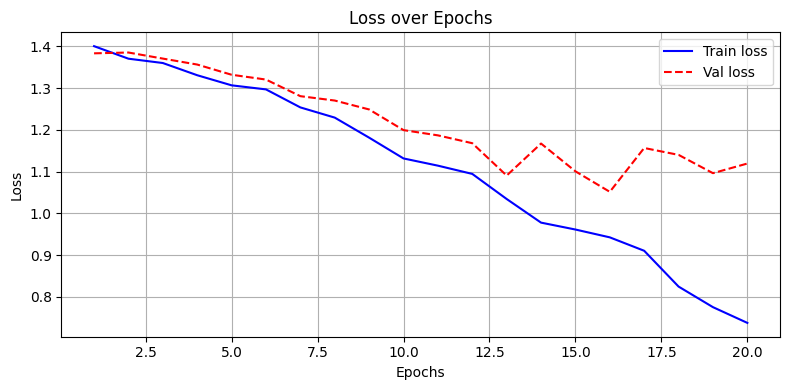

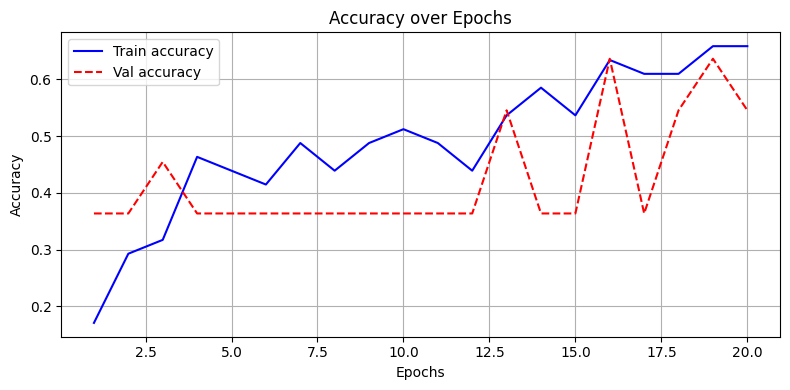

In [41]:
plot_training_history(intra_history, metrics=['loss', 'accuracy'])


## Grid hyperparameter search

In [42]:
'''adjust, apply random search to minimize search space'''
'''look at both accuracy and loss'''
# grid search parameters
cnn_filters = [32, 64]
kernel_sizes = [3, 5]
gru_units = [64, 128]
dense_sizes = [64, 128]
dropout_rates = [0.3, 0.5]
learning_rates = [1e-3, 5e-4]
bidirectional_opts = [True, False]
batch_sizes = [8, 16]
epochs = [20]

# create parameter combos
param_grid = list(itertools.product(
    cnn_filters, kernel_sizes, gru_units, dense_sizes,
    dropout_rates, learning_rates, bidirectional_opts,
    batch_sizes, epochs
))

results = []

# 
for cnn_f, ksize, gru_u, dense_s, drop_r, lr, bi, batch_s, epoch_n in param_grid:
    print(f"\nTesting config: CNN={cnn_f}, KSize={ksize}, GRU={gru_u}, Dense={dense_s}, Dropout={drop_r}, LR={lr}, BiGRU={bi}, Batch={batch_s}, Epochs={epoch_n}")
    
    # CNN
    def build_cnn(input_shape):
        inputs = layers.Input(shape=input_shape)
        x = layers.Conv1D(cnn_f, kernel_size=ksize, activation='relu')(inputs)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Conv1D(cnn_f * 2, kernel_size=3, activation='relu')(x)
        x = layers.GlobalAveragePooling1D()(x)
        return models.Model(inputs, x, name='cnn_encoder')
    
    # Full CNN-RNN aarchitecture
    def build_model(snapshot_shape, sequence_length, num_classes=4):
        cnn_encoder = build_cnn(snapshot_shape)
        inputs = layers.Input(shape=(sequence_length,) + snapshot_shape)
        x = layers.TimeDistributed(cnn_encoder)(inputs)

        if bi:
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=False))(x)
        else:
            x = layers.GRU(gru_u, return_sequences=False)(x)

        x = layers.Dropout(drop_r)(x)
        x = layers.Dense(dense_s, activation='relu')(x)
        x = layers.Dropout(drop_r)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        return model

    model = build_model(
        snapshot_shape=(X_all.shape[2], X_all.shape[3]),
        sequence_length=sequence_length,
        num_classes=4
    )

    optimizer = Adam(learning_rate=lr)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    #train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epoch_n,
        batch_size=batch_s,
        verbose=0
    )
    history_data = history.history
    best_val_acc = max(history.history['val_accuracy'])
    results.append({
        'val_accuracy': best_val_acc,
        'params': {
            'cnn_filters': cnn_f, 'kernel_size': ksize, 'gru_units': gru_u,
            'dense_size': dense_s, 'dropout': drop_r, 'learning_rate': lr,
            'bidirectional': bi, 'batch_size': batch_s, 'epochs': epoch_n
        },
         'history': history_data
    })

# find best combo
results.sort(key=lambda x: x['val_accuracy'], reverse=True)
print("\nTop 5 Configurations:")
for r in results[:5]:
    print(f"Val Acc: {r['val_accuracy']:.4f}, Params: {r['params']}")



Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.3, LR=0.001, BiGRU=True, Batch=8, Epochs=20

Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.3, LR=0.001, BiGRU=True, Batch=16, Epochs=20

Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.3, LR=0.001, BiGRU=False, Batch=8, Epochs=20

Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.3, LR=0.001, BiGRU=False, Batch=16, Epochs=20

Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.3, LR=0.0005, BiGRU=True, Batch=8, Epochs=20

Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.3, LR=0.0005, BiGRU=True, Batch=16, Epochs=20

Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.3, LR=0.0005, BiGRU=False, Batch=8, Epochs=20

Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.3, LR=0.0005, BiGRU=False, Batch=16, Epochs=20

Testing config: CNN=32, KSize=3, GRU=64, Dense=64, Dropout=0.5, LR=0.001, BiGRU=True, Batch=8, Epochs=20

Testing config: CNN=32, KSize=3, 

: 

Best Configuration:
  cnn_filters: 64
  kernel_size: 5
  gru_units: 128
  dense_size: 64
  dropout: 0.3
  learning_rate: 0.001
  bidirectional: True
  batch_size: 8
  epochs: 20


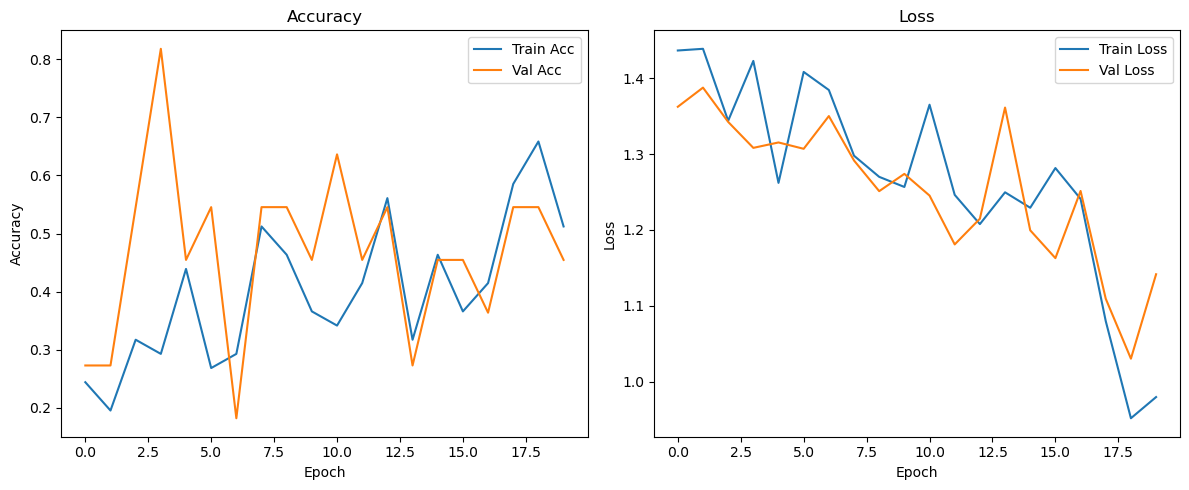

In [ ]:
# Sort by best validation accuracy
results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Get the best result
best_result = results[0]
best_history = best_result['history']

# Print best config
print("Best Configuration:")
for k, v in best_result['params'].items():
    print(f"  {k}: {v}")

# Plotting training and validation accuracy/loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_history['accuracy'], label='Train Acc')
plt.plot(best_history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_history['loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Testing

## Intra Testing

## Contra Testing